# RetinaNet 모델

In [1]:
### 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 0. 환경 준비
!nvidia-smi

Mon Mar 23 09:15:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   35C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### git 연결

In [3]:
# 1. 내 포크 clone
!git clone https://github.com/wina0901/pill_detection_project.git

# 2. 프로젝트 폴더로 이동
%cd pill_detection_project

# 3. requirements 설치
!pip install --upgrade pip
!pip install --index-url https://download.pytorch.org/whl/cu118 torch==2.7.1+cu118 torchvision==0.22.1+cu118 torchaudio==2.7.1+cu118
!pip install -r requirements.txt --no-deps


Cloning into 'pill_detection_project'...
remote: Enumerating objects: 403, done.
remote: Counting objects: 100% (67/67), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 403 (delta 15), reused 44 (delta 6), pack-reused 336 (from 1)
Receiving objects: 100% (403/403), 11.01 MiB | 16.56 MiB/s, done.
Resolving deltas: 100% (155/155), done.
/content/pill_detection_project
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 33.5 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 168.6 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 52.6 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 218.9 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 43.5 MB/s  0:00:07:00:0

In [4]:
import sys
import os
sys.path.append("/content/pill_detection_project")

from src.evaluation import (
    evaluate_all,
    init_history,
    update_history,
    save_history,
    load_history,
    plot_training_history,
    plot_compare_histories,
    convert_yolo_results,
    convert_torchvision_outputs,
)


# 데이터 가져오기

In [5]:
import os
from src.preprocessing.dataset import get_loaders

BASE_DIR = '/content/drive/MyDrive/data/초급_프로젝트/dataset'  # Colab 기준

train_loader, val_loader, orig2model, num_classes, VAL_JSON_PATH = get_loaders(
    base_dir=BASE_DIR,
    batch_size=4,
    num_workers=2,
)

✅ 고유 클래스 수  : 73종
✅ num_classes     : 74  ← 모델 정의 시 사용
✅ Train: 1790장 / 6134개
✅ Val  : 139장 / 431개


# 모델 학습

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)


DEVICE: cuda


In [7]:
############################################################
# RetinaNet
############################################################

import math
from torchvision.models.detection import retinanet_resnet50_fpn
from torchvision.models.detection.retinanet import RetinaNetClassificationHead
from torchvision.ops import sigmoid_focal_loss


class CustomRetinaNetClassificationHead(RetinaNetClassificationHead):
    def __init__(self, in_channels, num_anchors, num_classes, alpha=0.25, gamma=3.0, norm_layer=None):
        super().__init__(in_channels, num_anchors, num_classes, norm_layer=norm_layer)
        self.focal_alpha = alpha
        self.focal_gamma = gamma

    def compute_loss(self, targets, head_outputs, matched_idxs):
        cls_logits = head_outputs["cls_logits"]
        losses = []

        for targets_per_image, cls_logits_per_image, matched_idxs_per_image in zip(targets, cls_logits, matched_idxs):
            foreground_idxs_per_image = matched_idxs_per_image >= 0
            num_foreground = foreground_idxs_per_image.sum().item()

            gt_classes_target = torch.zeros_like(cls_logits_per_image)

            if num_foreground > 0:
                gt_classes_target[
                    foreground_idxs_per_image,
                    targets_per_image["labels"][matched_idxs_per_image[foreground_idxs_per_image]],
                ] = 1.0

            valid_idxs_per_image = matched_idxs_per_image != self.BETWEEN_THRESHOLDS

            losses.append(
                sigmoid_focal_loss(
                    cls_logits_per_image[valid_idxs_per_image],
                    gt_classes_target[valid_idxs_per_image],
                    alpha=self.focal_alpha,
                    gamma=self.focal_gamma,
                    reduction="sum",
                ) / max(1, num_foreground)
            )

        return sum(losses) / len(targets)


def build_retinanet_model(num_classes, focal_alpha=None, focal_gamma=None):
    model = retinanet_resnet50_fpn(weights="DEFAULT")
    cls_head = model.head.classification_head

    first_conv = next(
        module for module in cls_head.conv.modules() if isinstance(module, nn.Conv2d)
    )
    in_channels = first_conv.in_channels
    num_anchors = cls_head.num_anchors

    if focal_alpha is None and focal_gamma is None:
        model.head.classification_head = RetinaNetClassificationHead(
            in_channels=in_channels,
            num_anchors=num_anchors,
            num_classes=num_classes,
        )
    else:
        focal_alpha = 0.25 if focal_alpha is None else focal_alpha
        focal_gamma = 2.0 if focal_gamma is None else focal_gamma

        custom_head = CustomRetinaNetClassificationHead(
            in_channels=in_channels,
            num_anchors=num_anchors,
            num_classes=num_classes,
            alpha=focal_alpha,
            gamma=focal_gamma,
        )
        prior_probability = 0.01
        torch.nn.init.constant_(
            custom_head.cls_logits.bias,
            -math.log((1 - prior_probability) / prior_probability),
        )
        model.head.classification_head = custom_head

    return model

model = build_retinanet_model(num_classes)
model.to(DEVICE)

retina_optimizer = optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=1e-4,
    weight_decay=1e-4,
)
retina_scheduler = optim.lr_scheduler.StepLR(retina_optimizer, step_size=3, gamma=0.1)


Downloading: "https://download.pytorch.org/models/retinanet_resnet50_fpn_coco-eeacb38b.pth" to /root/.cache/torch/hub/checkpoints/retinanet_resnet50_fpn_coco-eeacb38b.pth


100%|██████████| 130M/130M [00:00<00:00, 212MB/s]  


In [8]:
############################################################
# RetinaNet Training Loop
############################################################

num_epochs = 30
patience = 10
min_delta = 1e-3

best_val_loss = float("inf")
early_stop_counter = 0
history = init_history()
model2orig = {v: k for k, v in orig2model.items()}

for epoch in range(1, num_epochs + 1):
    ##########################
    # 1) Train
    ##########################
    model.train()
    train_loss_sum = 0.0

    for images, targets in train_loader:
        images = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        retina_optimizer.zero_grad()
        losses.backward()
        retina_optimizer.step()

        train_loss_sum += losses.item()

    epoch_train_loss = train_loss_sum / max(1, len(train_loader))

    ##########################
    # 2) Validation loss
    ##########################
    model.train()  # detection models return loss values in train mode
    val_loss_sum = 0.0

    with torch.no_grad():
        for images, targets in val_loader:
            images = [img.to(DEVICE) for img in images]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            val_loss_sum += losses.item()

    epoch_val_loss = val_loss_sum / max(1, len(val_loader))

    ##########################
    # 3) Validation metrics (every epoch)
    ##########################
    all_outputs = []
    all_image_ids = []

    model.eval()
    with torch.no_grad():
        for images, targets in val_loader:
            images = [img.to(DEVICE) for img in images]
            outputs = model(images)

            batch_image_ids = [t["image_id"].item() for t in targets]
            all_outputs.extend(outputs)
            all_image_ids.extend(batch_image_ids)

    val_predictions = convert_torchvision_outputs(all_outputs, all_image_ids)
    metrics = evaluate_all(
        gt_json_path=VAL_JSON_PATH,
        predictions=val_predictions,
        conf_threshold=0.25,
        pr_iou_threshold=0.5,
        temp_json_path=f"retinanet_temp_eval_epoch_{epoch}.json",
        model2orig=model2orig,
    )

    update_history(
        history,
        epoch=epoch,
        train_loss=epoch_train_loss,
        val_loss=epoch_val_loss,
        metrics=metrics,
    )

    print(
        f"[RetinaNet Epoch {epoch}/{num_epochs}] "
        f"train_loss: {epoch_train_loss:.4f} | "
        f"val_loss: {epoch_val_loss:.4f} | "
        f"mAP@75:95: {metrics['mAP@75:95']:.4f} | "
        f"mAP@50: {metrics['mAP@50']:.4f} | "
        f"precision: {metrics['precision']:.4f} | "
        f"recall: {metrics['recall']:.4f}"
    )

    if epoch_val_loss < best_val_loss - min_delta:
        best_val_loss = epoch_val_loss
        early_stop_counter = 0
        torch.save(model.state_dict(), "retinanet_oral_drug.pth")
        print(f"  -> best val_loss updated: {best_val_loss:.4f}")
    else:
        early_stop_counter += 1
        print(f"  -> no improvement ({early_stop_counter}/{patience})")

    if early_stop_counter >= patience:
        print(f"Early stopping triggered: patience={patience}")
        break

    retina_scheduler.step()

save_history(history, "history_retinanet.json")
print("RetinaNet model and history saved")


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.10s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.58s).
Accumulating evaluation results...
DONE (t=0.72s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.232
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.237
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.237
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.167
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.234
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.792
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.924
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

# 모델 평가

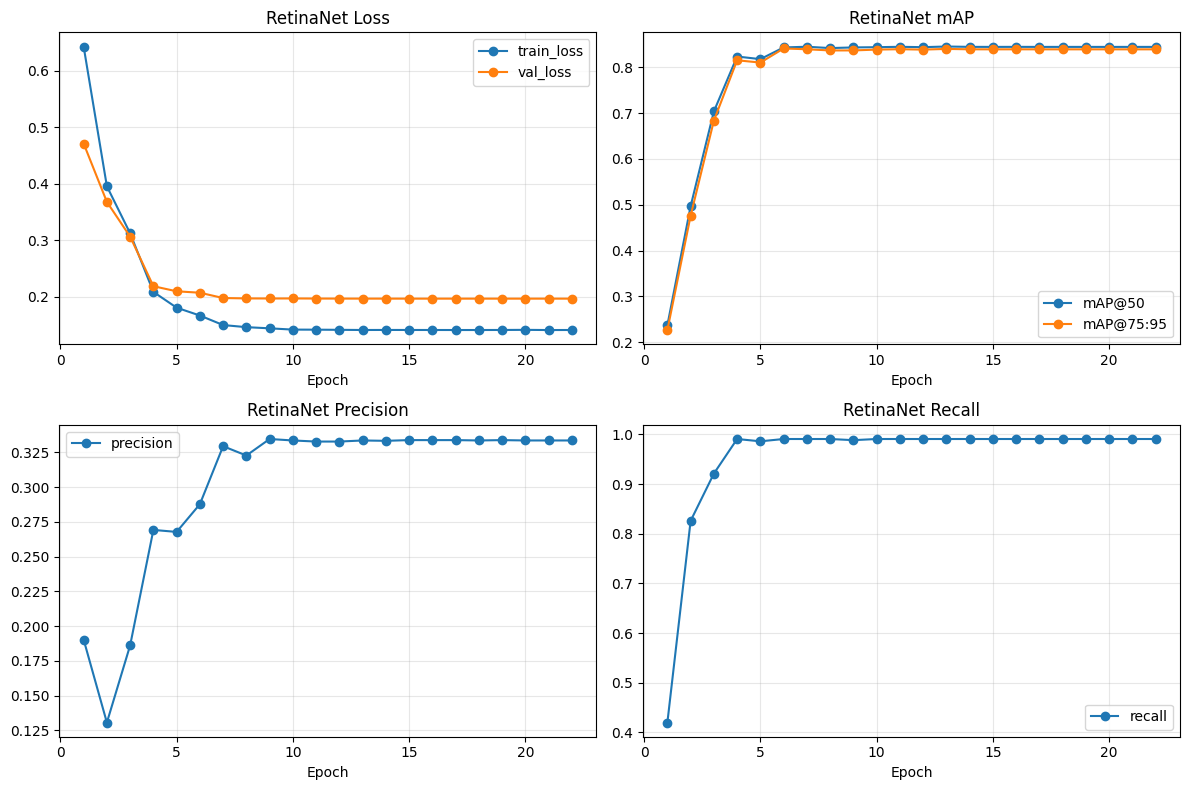

In [9]:
history = load_history("history_retinanet.json")
plot_training_history(history, title_prefix="RetinaNet")

# 추론

In [ ]:
############################################################
# 7. test_images -> submission.csv
############################################################

import os
import pandas as pd
from PIL import Image
import torchvision.transforms as T

TEST_IMG_DIR = os.path.join(BASE_DIR, "test_images")
OUTPUT_CSV_PATH = "/content/pill_detection_project/retinanet_test_submission.csv"
SCORE_THRESHOLD = 0.3
TOP_K_PER_IMAGE = 4
CATEGORY_ID_OFFSET = 0

if not os.path.isdir(TEST_IMG_DIR):
    raise FileNotFoundError(f"test_images folder not found: {TEST_IMG_DIR}")

test_files = sorted(
    f for f in os.listdir(TEST_IMG_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
)

if not test_files:
    raise FileNotFoundError(f"No test images found in: {TEST_IMG_DIR}")

model.eval()
rows = []

with torch.no_grad():
    for f in test_files:
        img_path = os.path.join(TEST_IMG_DIR, f)
        image = Image.open(img_path).convert("RGB")
        image_id = os.path.splitext(f)[0]

        img_tensor = T.ToTensor()(image).to(DEVICE)
        outputs = model([img_tensor])[0]

        keep = outputs["scores"].detach().cpu() >= SCORE_THRESHOLD
        boxes = outputs["boxes"].detach().cpu()[keep]
        labels = outputs["labels"].detach().cpu()[keep]
        scores = outputs["scores"].detach().cpu()[keep]

        per_image_rows = []
        for box, lab, sc in zip(boxes, labels, scores):
            x1, y1, x2, y2 = box.tolist()
            orig_cat = model2orig[int(lab.item())]
            per_image_rows.append({
                "image_id": image_id,
                "category_id": int(orig_cat + CATEGORY_ID_OFFSET),
                "bbox_x": float(x1),
                "bbox_y": float(y1),
                "bbox_w": float(x2 - x1),
                "bbox_h": float(y2 - y1),
                "score": float(sc.item()),
            })

        per_image_rows = sorted(
            per_image_rows,
            key=lambda x: x["score"],
            reverse=True,
        )[:TOP_K_PER_IMAGE]
        rows.extend(per_image_rows)

if not rows:
    print("No predictions passed the score threshold.")
    df_sub = pd.DataFrame(columns=[
        "annotation_id", "image_id", "category_id",
        "bbox_x", "bbox_y", "bbox_w", "bbox_h", "score"
    ])
else:
    df_sub = pd.DataFrame(rows, columns=[
        "image_id", "category_id",
        "bbox_x", "bbox_y", "bbox_w", "bbox_h", "score"
    ])
    df_sub = df_sub.sort_values(by=["image_id", "score"], ascending=[True, False])
    df_sub = df_sub.groupby("image_id", as_index=False, group_keys=False).head(TOP_K_PER_IMAGE)
    df_sub.insert(0, "annotation_id", range(1, len(df_sub) + 1))

df_sub.to_csv(OUTPUT_CSV_PATH, index=False)

print(f"Saved csv: {OUTPUT_CSV_PATH}")
print(f"Total predicted boxes: {len(df_sub)}")
df_sub.head()


Saved csv: /content/drive/MyDrive/data/초급_프로젝트/dataset/retinanet_test_submission.csv
Total predicted boxes: 3369


,annotation_id,image_id,category_id,bbox_x,bbox_y,bbox_w,bbox_h,score
0,1,1,31884,584.605957,74.981956,363.360596,395.416054,0.803867
1,2,1,31704,170.902054,741.682678,182.803024,292.716736,0.544398
2,3,1,34596,570.190613,79.402351,373.165527,391.431541,0.446021
3,4,1,23222,603.385681,683.664062,241.920105,472.295898,0.410006
4,5,10,3742,102.683266,807.576050,243.939415,236.030273,0.562727


# 시각화

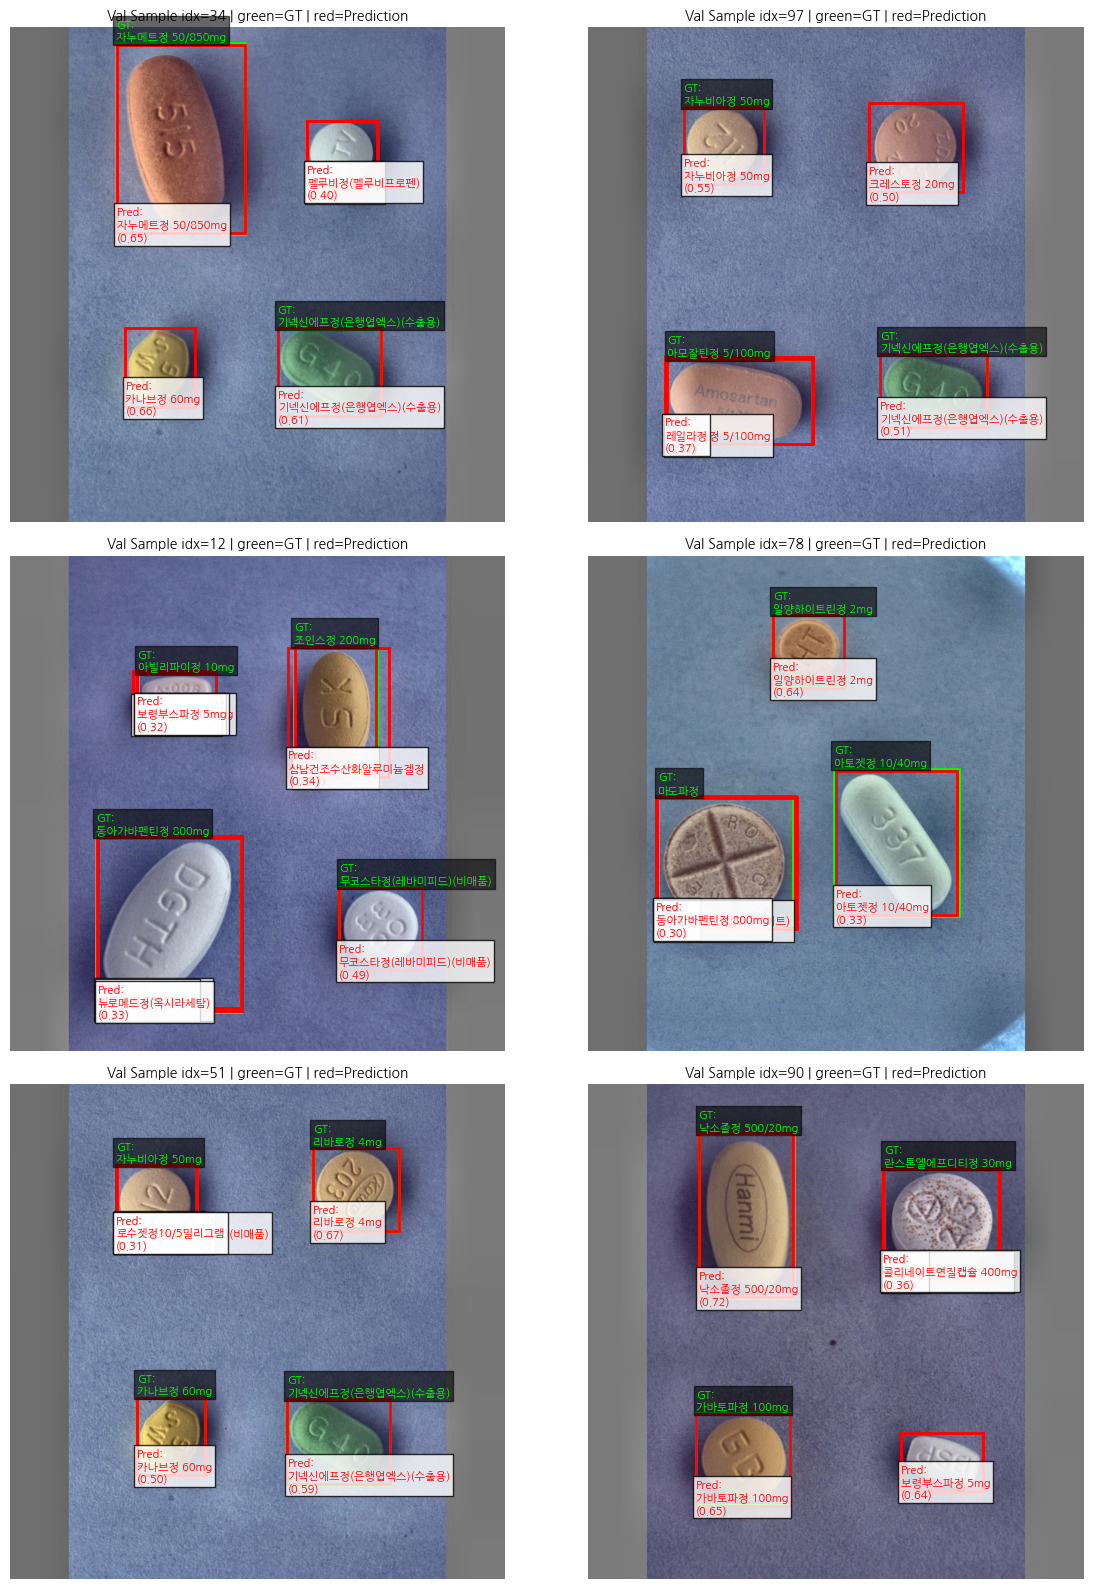

In [14]:
import json
import os
import random
import shutil
import subprocess
import textwrap
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.font_manager as fm
from matplotlib.font_manager import FontProperties
import torch

def configure_colab_font():
    if shutil.which("apt-get"):
        subprocess.run(
            ["apt-get", "-qq", "install", "-y", "fonts-nanum", "fonts-nanum-extra"],
            check=False,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )

    if shutil.which("fc-cache"):
        subprocess.run(
            ["fc-cache", "-fv"],
            check=False,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )

    fm._load_fontmanager(try_read_cache=False)
    font_candidates = [
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
        "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    ]

    selected_path = next((path for path in font_candidates if os.path.exists(path)), None)

    if selected_path is not None:
        font_prop = FontProperties(fname=selected_path)
        selected_font = font_prop.get_name()
    else:
        available_fonts = {font.name for font in fm.fontManager.ttflist}
        preferred_fonts = [
            "NanumGothic",
            "NanumBarunGothic",
            "Noto Sans CJK KR",
            "Noto Sans KR",
            "DejaVu Sans",
        ]
        selected_font = next((name for name in preferred_fonts if name in available_fonts), "DejaVu Sans")
        font_prop = FontProperties(family=selected_font)

    plt.rcParams["font.family"] = [selected_font, "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False
    return font_prop, selected_font

font_prop, font_name = configure_colab_font()

with open(VAL_JSON_PATH, "r", encoding="utf-8") as f:
    val_coco = json.load(f)

cat_id_to_name = {c["id"]: c["name"] for c in val_coco["categories"]}
model2orig = {v: k for k, v in orig2model.items()}

NUM_SAMPLES = 6
SCORE_THRESH = 0.3
N_COLS = 2
N_ROWS = 3

def wrap_label(prefix, name, width=18, score=None):
    wrapped_name = "\n".join(textwrap.wrap(str(name), width=width))
    if score is None:
        return f"{prefix}:\n{wrapped_name}"
    return f"{prefix}:\n{wrapped_name}\n({score:.2f})"

sample_indices = random.sample(
    range(len(val_loader.dataset)),
    k=min(NUM_SAMPLES, len(val_loader.dataset))
)

model.eval()

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(12, 16))
axes = axes.flatten()

with torch.no_grad():
    for ax, idx in zip(axes, sample_indices):
        image, target = val_loader.dataset[idx]
        output = model([image.to(DEVICE)])[0]

        img_np = image.permute(1, 2, 0).cpu().numpy()
        ax.imshow(img_np)
        ax.axis("off")

        gt_boxes = target["boxes"].cpu().numpy()
        gt_labels = target["labels"].cpu().numpy()

        for box, label in zip(gt_boxes, gt_labels):
            x1, y1, x2, y2 = box
            orig_cat = model2orig.get(int(label), int(label))
            pill_name = cat_id_to_name.get(orig_cat, str(orig_cat))

            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor="lime", facecolor="none"
            )
            ax.add_patch(rect)

            ax.text(
                x1, max(y1 - 5, 5),
                wrap_label("GT", pill_name, width=18),
                color="lime",
                fontsize=8,
                bbox=dict(facecolor="black", alpha=0.6, pad=2),
                fontproperties=font_prop
            )

        pred_boxes = output["boxes"].detach().cpu().numpy()
        pred_scores = output["scores"].detach().cpu().numpy()
        pred_labels = output["labels"].detach().cpu().numpy()

        for box, score, label in zip(pred_boxes, pred_scores, pred_labels):
            if score < SCORE_THRESH:
                continue

            x1, y1, x2, y2 = box
            orig_cat = model2orig.get(int(label), int(label))
            pill_name = cat_id_to_name.get(orig_cat, str(orig_cat))

            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor="red", facecolor="none"
            )
            ax.add_patch(rect)

            ax.text(
                x1, min(y2 + 12, img_np.shape[0] - 5),
                wrap_label("Pred", pill_name, width=18, score=score),
                color="red",
                fontsize=8,
                bbox=dict(facecolor="white", alpha=0.8, pad=2),
                fontproperties=font_prop
            )

        ax.set_title(
            f"Val Sample idx={idx} | green=GT | red=Prediction",
            fontproperties=font_prop,
        )

for ax in axes[len(sample_indices):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


# 가중치 및 학습 결과 구글 드라이브에 저장

In [15]:
import os
import shutil

SAVE_DIR = "/content/drive/MyDrive/pill_detection_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

shutil.copy("/content/pill_detection_project/retinanet_oral_drug.pth", SAVE_DIR)
shutil.copy("/content/pill_detection_project/history_retinanet.json", SAVE_DIR)
# shutil.copy("/content/pill_detection_project/retinanet_test_submission.csv", SAVE_DIR)

print(os.listdir(SAVE_DIR))

['retinanet_oral_drug.pth', 'history_retinanet.json']


In [16]:
import requests

webhook_url = "https://discord.com/api/webhooks/1484101399792058379/RmmWK-rC4qJhpDUJtgO9OwEwMzLuUJ-_NNp62V33g1_Cny5sg13MhOE4RV3sMCy8D4M5"
data = {"content": "RetinaNet 학습이 완료됐습니다."}
requests.post(webhook_url, json=data)


<Response [204]>